In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def auto_preprocess_for_vllm(image_path, auto_sharpen=True, show_steps=True):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"图像无法读取: {image_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 是否自动锐化判断
    final = gray
    if auto_sharpen:
        edges = cv2.Canny(gray, 50, 150)
        edge_ratio = np.sum(edges > 0) / edges.size
        if edge_ratio < 0.04:
            blurred = cv2.GaussianBlur(gray, (9, 9), 10.0)
            final = cv2.addWeighted(gray, 1.3, blurred, -0.3, 0)

    if show_steps:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.title("Grayscale")
        plt.imshow(gray, cmap='gray')
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Final Image (Auto Sharpened)" if not np.array_equal(final, gray) else "Final Image (Raw Grayscale)")
        plt.imshow(final, cmap='gray')
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return final
 # 适用于保存、送入识别等用途


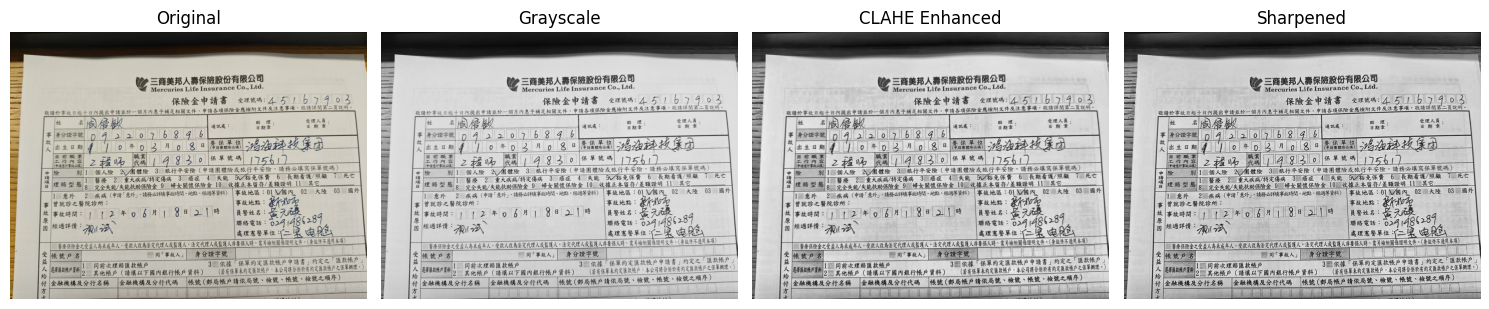

True

In [18]:
# 图像路径
img_path = "442.jpg"

# 返回处理后的图（灰度 + CLAHE + 可能锐化）
processed_img = auto_preprocess_for_vllm(img_path)

# 如果要保存为新图送入识别：
cv2.imwrite("processed_for_vllm.jpg", processed_img)

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_blur_score(gray_image):
    laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
    return laplacian.var()

def auto_sharpen(image_path, save_path=None, show_steps=True):
    # 读取图像
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"无法读取图像: {image_path}")

    # 转灰度
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 估算清晰度（方差越高越清晰）
    blur_score = estimate_blur_score(gray)

    # 决定锐化强度
    if blur_score < 50:
        # 非常模糊：强烈锐化
        alpha, beta, sigma = 1.8, 0.8, 3.0
        sharpen_level = "Strong"
    elif blur_score < 150:
        # 普通模糊：中等锐化
        alpha, beta, sigma = 1.5, 0.5, 2.0
        sharpen_level = "Medium"
    elif blur_score < 300:
        # 轻度模糊：轻柔锐化
        alpha, beta, sigma = 1.3, 0.3, 1.5
        sharpen_level = "Light"
    else:
        # 足够清晰：跳过锐化
        sharpened = gray
        sharpen_level = "None"

    if sharpen_level != "None":
        blurred = cv2.GaussianBlur(gray, (7, 7), sigma)
        sharpened = cv2.addWeighted(gray, alpha, blurred, -beta, 0)

    if show_steps:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.title("Original")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title(f"Grayscale (Score={blur_score:.1f})")
        plt.imshow(gray, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(f"Sharpened ({sharpen_level})")
        plt.imshow(sharpened, cmap='gray')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    if save_path:
        cv2.imwrite(save_path, sharpened)
        print(f"图像已保存：{save_path}")

    return sharpened


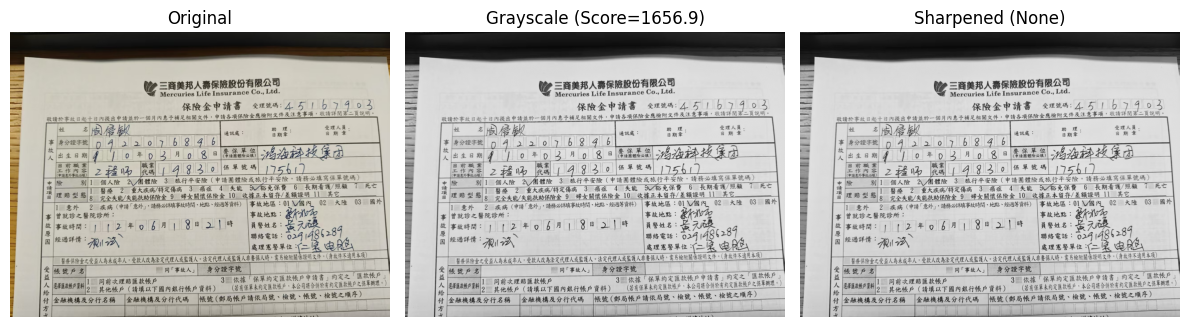

图像已保存：442_auto_sharpened.jpg


array([[ 44,  44,  44, ...,  12,  12,  12],
       [ 39,  39,  38, ...,  11,  11,  11],
       [ 47,  48,  50, ...,  10,  10,  10],
       ...,
       [ 51,  48,  53, ..., 160, 159, 159],
       [ 66,  63,  67, ..., 159, 158, 158],
       [ 60,  57,  62, ..., 159, 159, 159]], dtype=uint8)

In [22]:
auto_sharpen("442.jpg", "442_auto_sharpened.jpg")